In [44]:
import numpy as np
from lgdo import lh5
from pathlib import Path
from matplotlib import pyplot as plt
import tol_colors as tc
import hist
import math
import awkward as ak
from scipy.stats import beta, poisson, norm
import dbetto
import matplotlib.colors as colors
import copy

plt.rcParams["lines.linewidth"] = 1
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["font.size"] = 12
vib = tc.tol_cset("vibrant")
vset = tc.tol_cset("vibrant")
mset = tc.tol_cset("muted")
tol_vib_muted = [
    "#EE6677", "#4477AA", "#228833", "#CCBB44", "#66CCEE", "#AA3377", "#BBBBBB",  # Vibrant
]

# Set Matplotlib color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=tol_vib_muted)

style = {
    "yerr": False,
    "flow": None,
    "fill": False,
    "lw": 1.5,
}

# Get the BuPu colormap
cmap = plt.get_cmap("cividis")

In [6]:

def get_lh5(generator, name, val):
    path = f"{generator}/{name}/max_{val}/"
    stp_directory = Path(f"out/{path}/stp/")
    data = lh5.read_as("stp/germanium", f"{stp_directory}/out_t0.lh5",library= "ak")
    return data


In [18]:
def plot_tracks(data,idx,zoom = False):
    
    n = 3 if zoom else 2
    fig,ax=plt.subplots(1,n)
    
    evtids = np.unique(data.evtid)
    data_tmp = data[data.evtid==evtids[idx]]

    for i in range(n):
        factor = 1 if i<2 else 1000
        if (i==0):
            data_tmp = data_tmp[1:]
        for idx,track in enumerate(data_tmp.trackid):
            label= "tracks" if idx==0 else None
            
            ax[i].plot(1000*factor*data_tmp[data_tmp.trackid==track].xloc,1000*factor*data_tmp[data_tmp.trackid==track].zloc+5*factor,
                       alpha=1,linewidth=1,label=label,color=vset.blue)

        
        ax[i].scatter(1000*factor*data_tmp.xloc,1000*factor*data_tmp.zloc+5*factor,s=20)

        prefix = "m" if i<2 else "u"
        ax[i].set_xlabel(f"x [{prefix}m]")
        ax[i].set_ylabel(f"z [{prefix}m]")
        if (i==1):
            ax[i].set_xlim(-10,10)
            ax[i].set_ylim(-1,11)
  
            ax[i].axhspan(max(0,ax[i].get_ylim()[0]),min(10,ax[i].get_ylim()[1]),alpha=0.1,color="grey",label="HPGe")
        if (i==2):
            ax[i].set_ylim(-0.0,20)  
            ax[i].set_xlim(-100,100)  

            ax[i].axhspan(max(0,ax[i].get_ylim()[0]),min(1000,ax[i].get_ylim()[1]),alpha=0.1,color="grey",label="HPGe")
        
    ax[1].legend(fontsize=14)
    plt.tight_layout()

In [13]:
def get_binomial_interval(npass, n):
    eff = npass / n
    quantiles = beta.ppf([0.16, 0.84], npass + 1, n - npass + 1)
    err_low = eff - quantiles[0]
    err_high = quantiles[1] - eff
    if err_high <= 0:
        quantiles = beta.ppf([1 - 0.68, 1], npass + 1, n - npass + 1)
        err_low = eff - quantiles[0]
        err_high = quantiles[1] - eff
    elif err_low <= 0:
        quantiles = beta.ppf([0, 0.68], npass + 1, n - npass + 1)
        err_low = eff - quantiles[0]
        err_high = quantiles[1] - eff
    return err_low, err_high

In [41]:
def plot_hist2d(dist, step_len, n=-1, high_stp=300, high_dist=5000, bins=500):
    fig, ax = plt.subplots(1, 1)
    
    # Create a 2D histogram
    h = ax.hist2d(dist[:n].to_numpy(), step_len[:n].to_numpy(), bins=bins, range=[[0, high_dist], [0, high_stp]], cmap="BuPu", norm=colors.LogNorm())
    
    # Add colorbar
    c = plt.colorbar(h[3], ax=ax, label="Counts")
    ax.set_xlabel("Distance to Surface [um]")
    ax.set_ylabel("Step length [um]")

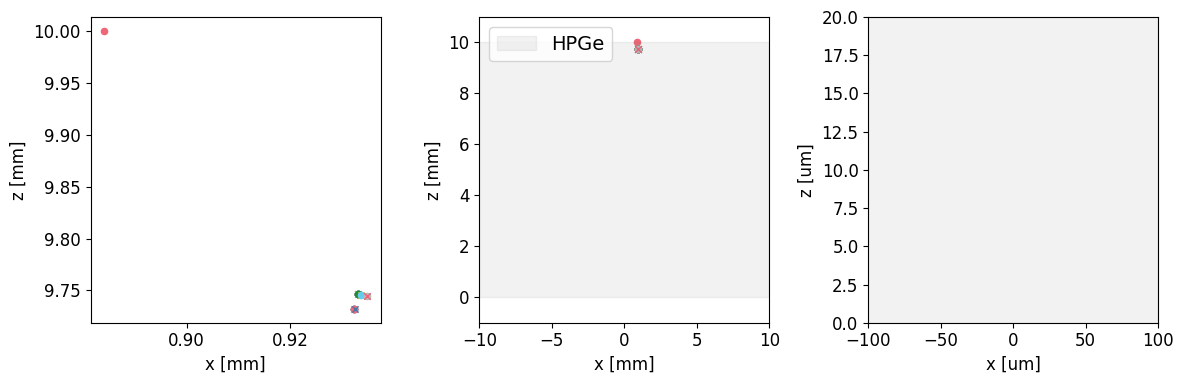

In [9]:
data = get_lh5("am241","step_limits_all",20)

plot_tracks(data,idx=1,zoom=True)

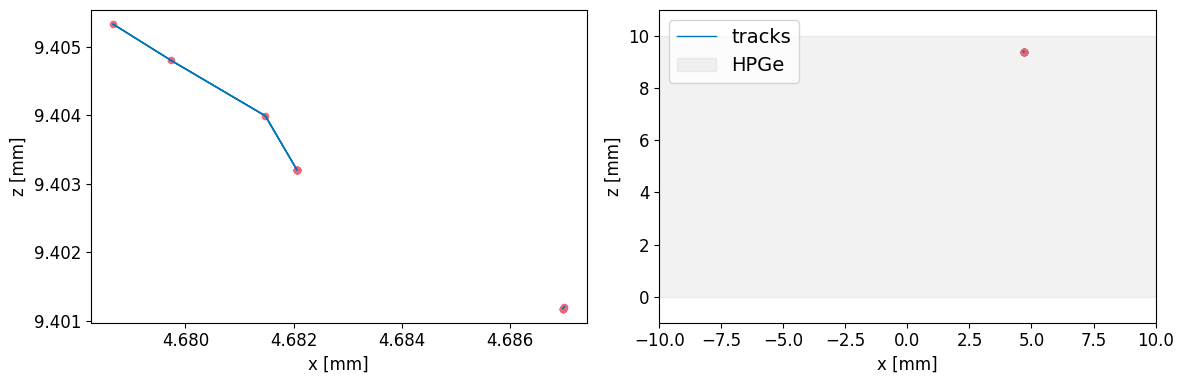

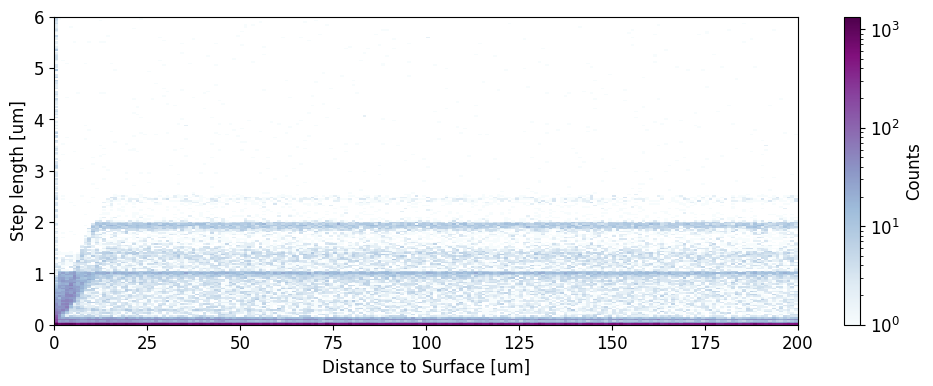

In [70]:
data = get_lh5("am241","step_limits_all",5)
plot_tracks(data,idx=1,zoom=False)
length = np.sqrt((data.xloc-data.xloc_post)**2+(data.yloc-data.yloc_post)**2+(data.zloc-data.zloc_post)**2)
plot_hist2d(1e6*data.dist_to_surf,1e6*length,high_stp=6,high_dist=200,bins=200)

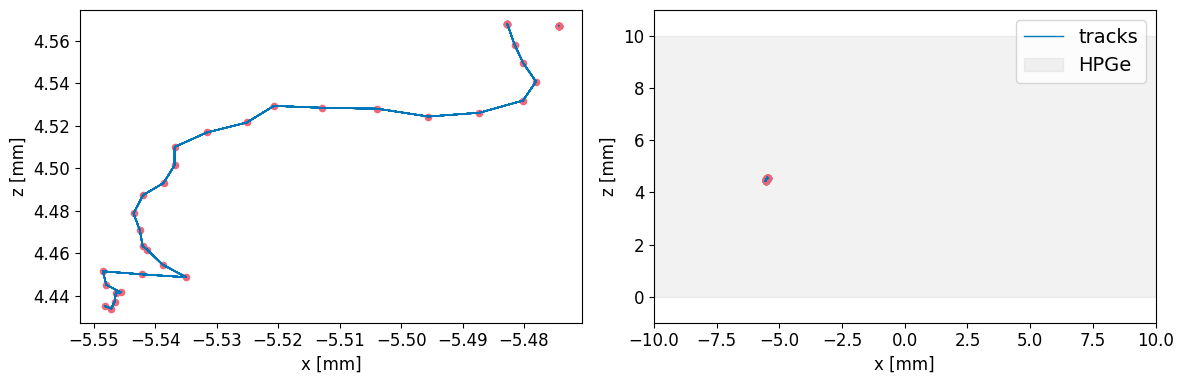

In [66]:
data = get_lh5("ba133","step_limits_all",10)
plot_tracks(data,idx=1,zoom=False)
length = np.sqrt((data.xloc-data.xloc_post)**2+(data.yloc-data.yloc_post)**2+(data.zloc-data.zloc_post)**2)

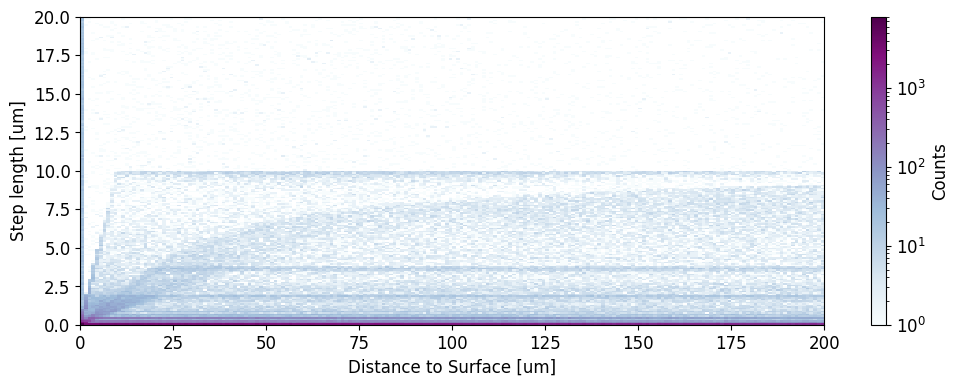

In [64]:
plot_hist2d(1e6*data.dist_to_surf,1e6*length,high_stp=20,high_dist=200,bins=200)